# CSCE 676 — Project Checkpoint 2  
## Research Question Formation


## Collaboration Declaration

**Collaborators:** None

**Web Sources:**
- SNAP Facebook Combined Graph dataset  
  https://snap.stanford.edu/data/facebook_combined.txt.gz
- SNAP dataset page  
  https://snap.stanford.edu/data/facebook_combined.html

**AI Tools:**
- ChatGPT (used for notebook structure, explanation drafting, and code refinement)

**Citations / Papers Used:**
- Leskovec, J., & Krevl, A. (2014). SNAP Datasets: Stanford Large Network Dataset Collection.
  https://snap.stanford.edu/data/

- Newman, M. (2003). The structure and function of complex networks.
  https://www.pnas.org/doi/10.1073/pnas.0307545100

- Fortunato, S. (2010). Community detection in graphs.
  https://arxiv.org/abs/0906.0612

- Grover, A., & Leskovec, J. (2016). node2vec: Scalable feature learning for networks.
  https://snap.stanford.edu/node2vec/

- Zhang, D., Yin, J., Zhu, X., & Zhang, C. (2018). Network representation learning: A survey.
  https://arxiv.org/abs/1801.05852

- Kovács, B., Kojaku, S., Palla, G., & Fortunato, S. (2024).
  Iterative embedding and reweighting of complex networks reveals community structure.
  https://arxiv.org/abs/2402.10813

## Project Scope

- **Dataset:** SNAP Facebook Combined Graph, an undirected social network with 4039 nodes and 88,234 edges.
- **Checkpoint 1 findings:** The graph is sparse but fully connected, has a highly skewed degree distribution, contains hub nodes, and shows uneven community structure.
- **Course techniques:** Graph mining, centrality analysis, community detection, and clustering-oriented analysis.
- **External direction:** Graph embeddings and embedding-based structural analysis.

## Environment Setup

In this step, we import the required libraries for graph analysis, clustering, embeddings, and similarity search, and fix a random seed for reproducibility. This ensures that all stochastic components such as clustering and embedding projections produce consistent results across runs, which is important for debugging, validation, and fair comparison of methods.

In [44]:
import os
import random
import gzip
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.sparse.linalg import eigsh
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [45]:
DATA_URL = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
RAW_GZ_PATH = Path("data") / "facebook_combined.txt.gz"
DATA_PATH = Path("data") / "facebook_combined.txt"

os.makedirs("data", exist_ok=True)

def download_dataset(url: str, to_path: Path):
    if to_path.exists():
        print(f"Dataset already downloaded: {to_path}")
        return
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, to_path)
    print(f"Saved to {to_path} ({os.path.getsize(to_path)/(1024*1024):.2f} MB)")

def extract_gz(gz_path: Path, out_path: Path):
    if out_path.exists():
        print(f"Extracted file already exists: {out_path}")
        return
    with gzip.open(gz_path, "rb") as f_in:
        with open(out_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    print(f"Extracted to {out_path}")

download_dataset(DATA_URL, RAW_GZ_PATH)
extract_gz(RAW_GZ_PATH, DATA_PATH)

Dataset already downloaded: data/facebook_combined.txt.gz
Extracted file already exists: data/facebook_combined.txt


## Data Acquisition

We download and extract the dataset programmatically to ensure reproducibility and avoid missing-file errors. Using the compressed format reduces storage overhead, while extraction ensures compatibility with data processing tools.

In [31]:
def load_edges(path: Path) -> pd.DataFrame:
    """
    Load SNAP edge list as a dataframe.

    WHY:
    - dtype=str avoids accidental numeric casting issues for node IDs.
    - dropna handles rare malformed rows safely.
    """
    return pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["src", "dst"],
        dtype=str,
        engine="python"
    ).dropna()

def clean_edges(df: pd.DataFrame, undirected: bool = True) -> pd.DataFrame:
    """
    Clean edge list.

    WHY:
    - Remove self-loops because they do not represent meaningful social ties here.
    - Remove duplicates so graph metrics are not inflated.
    - Canonicalize undirected edges so (u,v) and (v,u) are treated as the same edge.
    """
    cleaned = df.copy()
    cleaned = cleaned[cleaned["src"] != cleaned["dst"]]

    if undirected:
        u = np.minimum(cleaned["src"].values, cleaned["dst"].values)
        v = np.maximum(cleaned["src"].values, cleaned["dst"].values)
        cleaned = pd.DataFrame({"src": u, "dst": v})

    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    return cleaned

edges_raw = load_edges(DATA_PATH)
edges = clean_edges(edges_raw, undirected=True)
G = nx.from_pandas_edgelist(edges, source="src", target="dst", create_using=nx.Graph())

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Self-loops:", nx.number_of_selfloops(G))
edges.head()

Nodes: 4039
Edges: 88234
Self-loops: 0


,src,dst
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


## Loading and Cleaning

We load the edge list into a dataframe, remove self-loops, eliminate duplicate edges, and construct an undirected graph with canonical edge ordering. These preprocessing steps are necessary because graph metrics such as degree, centrality, and community detection are highly sensitive to structural artifacts, and cleaning ensures that the analysis reflects true network structure rather than noise or duplication.

In [32]:
assert G.number_of_nodes() == 4039, "Unexpected node count"
assert G.number_of_edges() == 88234, "Unexpected edge count"
assert nx.number_of_selfloops(G) == 0, "Self-loops remain after cleaning"
assert (edges["src"] <= edges["dst"]).all(), "Undirected canonicalization failed"

print("All integrity checks passed.")

All integrity checks passed.


## Validation Checks

We run integrity checks on node count, edge count, absence of self-loops, and proper canonicalization of edges to verify that preprocessing was applied correctly. These tests ensure that the graph structure matches expected properties and that downstream analyses are based on a valid and consistent dataset.

In [33]:
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc_nodes).copy()

# Centrality
deg_cent = nx.degree_centrality(G_cc)
bet_cent = nx.betweenness_centrality(G_cc, k=min(200, G_cc.number_of_nodes()), seed=SEED)
pagerank_scores = nx.pagerank(G_cc)

def top_k(metric_dict: dict, k: int = 10) -> pd.DataFrame:
    return pd.DataFrame(
        sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:k],
        columns=["node", "score"]
    )

top_degree = top_k(deg_cent, 10)
top_betweenness = top_k(bet_cent, 10)
top_pagerank = top_k(pagerank_scores, 10)

# Communities
from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G_cc))
node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

# Embeddings
def spectral_embedding(graph: nx.Graph, dim: int = 16):
    nodes = list(graph.nodes())
    adjacency = nx.to_scipy_sparse_array(graph, nodelist=nodes, dtype=float)
    k = min(dim, graph.number_of_nodes() - 1)
    _, vectors = eigsh(adjacency, k=k, which="LM")
    return vectors, nodes

embedding, emb_nodes = spectral_embedding(G_cc, dim=16)
assert np.isfinite(embedding).all(), "Embedding contains NaN or Inf"

# PCA projection
pca = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(embedding)

summary = {
    "Connected Components": nx.number_connected_components(G),
    "Largest CC Size": len(largest_cc_nodes),
    "Number of Communities": len(communities),
    "Embedding Shape": embedding.shape
}
summary

{'Connected Components': 1,
 'Largest CC Size': 4039,
 'Number of Communities': 16,
 'Embedding Shape': (4039, 16)}

## Additional EDA

To identify stronger and more meaningful research questions, I perform additional EDA beyond Checkpoint 1. In particular, I examine multiple notions of node importance, community size variation, embedding structure, and structural roles such as hubs, bridges, and peripheral nodes. These analyses help determine which graph patterns are distinctive enough to motivate a focused project question and whether the proposed methods are computationally feasible.

In [34]:
# Additional EDA 1: Compare different notions of node importance

def top_k(metric_dict: dict, k: int = 10) -> pd.DataFrame:
    """Return top-k nodes for a centrality dictionary."""
    return pd.DataFrame(
        sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:k],
        columns=["node", "score"]
    )

top_degree = top_k(deg_cent, 10).rename(columns={"score": "degree_centrality"})
top_betweenness = top_k(bet_cent, 10).rename(columns={"score": "betweenness_centrality"})
top_pagerank = top_k(pagerank_scores, 10).rename(columns={"score": "pagerank"})

print("Top nodes by degree centrality")
display(top_degree)

print("Top nodes by betweenness centrality")
display(top_betweenness)

print("Top nodes by PageRank")
display(top_pagerank)

Top nodes by degree centrality


,node,degree_centrality
0,107,0.258791
1,1684,0.196137
2,1912,0.186974
3,3437,0.135463
4,0,0.085934
5,2543,0.072808
6,2347,0.072065
7,1888,0.062902
8,1800,0.060674
9,1663,0.058197


Top nodes by betweenness centrality


,node,betweenness_centrality
0,107,0.490675
1,1684,0.360696
2,1912,0.226122
3,3437,0.214248
4,0,0.147377
5,1085,0.142369
6,698,0.101550
7,58,0.087988
8,567,0.084213
9,428,0.060792


Top nodes by PageRank


,node,pagerank
0,3437,0.007615
1,107,0.006936
2,1684,0.006367
3,0,0.006290
4,1912,0.003877
5,348,0.002348
6,686,0.002219
7,3980,0.002170
8,414,0.001800
9,698,0.001317


In [35]:
# Additional EDA 2: Overlap among top-k centrality rankings

top_deg_nodes = set(top_degree["node"])
top_bet_nodes = set(top_betweenness["node"])
top_pr_nodes = set(top_pagerank["node"])

overlap_df = pd.DataFrame({
    "Comparison": [
        "Degree vs Betweenness",
        "Degree vs PageRank",
        "Betweenness vs PageRank"
    ],
    "Top-10 Overlap": [
        len(top_deg_nodes & top_bet_nodes),
        len(top_deg_nodes & top_pr_nodes),
        len(top_bet_nodes & top_pr_nodes)
    ]
})

overlap_df

,Comparison,Top-10 Overlap
0,Degree vs Betweenness,5
1,Degree vs PageRank,5
2,Betweenness vs PageRank,6


,community_size
count,16.000000
mean,252.437500
std,311.067189
min,3.000000
25%,21.250000
50%,132.500000
75%,403.250000
max,1031.000000


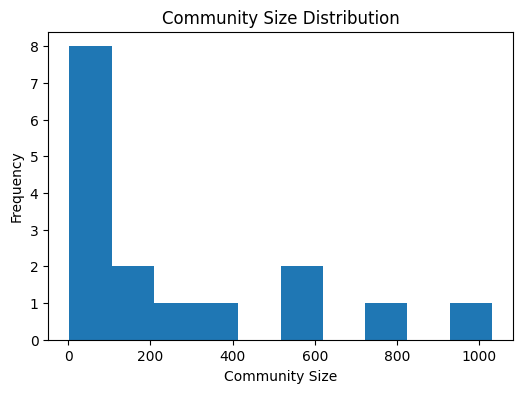

In [36]:
# Additional EDA 3: Community size distribution

community_sizes = pd.Series([len(c) for c in communities], name="community_size")

display(community_sizes.describe())

plt.figure(figsize=(6, 4))
plt.hist(community_sizes, bins=10)
plt.title("Community Size Distribution")
plt.xlabel("Community Size")
plt.ylabel("Frequency")
plt.show()

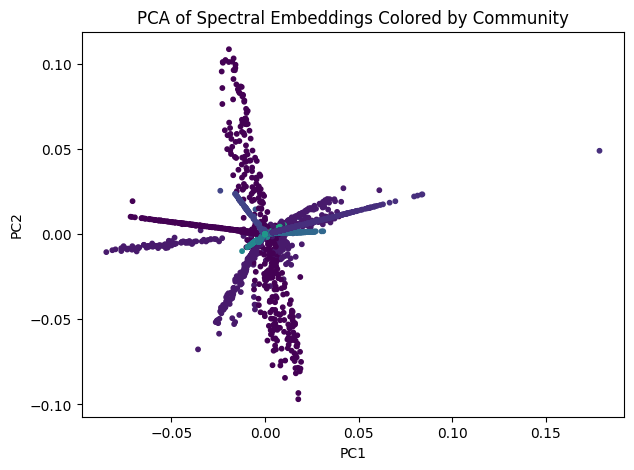

In [37]:
# Additional EDA 4: Visualize embedding structure by community

community_colors = np.array([node_to_comm[n] for n in emb_nodes])

plt.figure(figsize=(7, 5))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=community_colors, s=10)
plt.title("PCA of Spectral Embeddings Colored by Community")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [38]:
# Additional EDA 5: Define structural roles based on degree and betweenness

degree_series = pd.Series({n: G_cc.degree(n) for n in G_cc.nodes()}, name="degree")
betweenness_series = pd.Series(bet_cent, name="betweenness")

high_degree_threshold = degree_series.quantile(0.90)
high_bet_threshold = betweenness_series.quantile(0.90)
low_degree_threshold = degree_series.quantile(0.25)

role_map = {}

for node in G_cc.nodes():
    degree_value = degree_series[node]
    betweenness_value = betweenness_series[node]

    if degree_value >= high_degree_threshold:
        role_map[node] = "hub"
    elif betweenness_value >= high_bet_threshold:
        role_map[node] = "bridge"
    elif degree_value <= low_degree_threshold:
        role_map[node] = "peripheral"
    else:
        role_map[node] = "other"

role_counts = pd.Series(role_map).value_counts().rename_axis("role").reset_index(name="count")
role_counts

,role,count
0,other,2311
1,peripheral,1031
2,hub,404
3,bridge,293


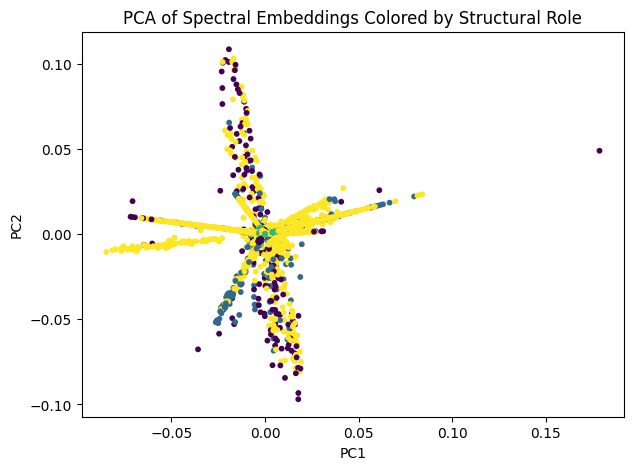

In [39]:
# Additional EDA 6: Visualize embeddings by structural role

role_to_id = {"hub": 0, "bridge": 1, "peripheral": 2, "other": 3}
role_colors = np.array([role_to_id[role_map[n]] for n in emb_nodes])

plt.figure(figsize=(7, 5))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=role_colors, s=10)
plt.title("PCA of Spectral Embeddings Colored by Structural Role")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [40]:
# Additional EDA 7: Community membership of top central nodes

top_central_nodes = list(top_degree["node"])

top_central_community_df = pd.DataFrame({
    "node": top_central_nodes,
    "community": [node_to_comm[n] for n in top_central_nodes],
    "degree": [G_cc.degree(n) for n in top_central_nodes],
    "betweenness": [bet_cent[n] for n in top_central_nodes]
})

top_central_community_df

,node,community,degree,betweenness
0,107,0,1045,0.490675
1,1684,0,792,0.360696
2,1912,3,755,0.226122
3,3437,2,547,0.214248
4,0,4,347,0.147377
5,2543,3,294,0.005951
6,2347,3,291,0.002521
7,1888,0,254,0.000174
8,1800,0,245,0.000287
9,1663,0,235,0.001359


In [41]:
# Additional EDA 8: Feasibility check using clustering in embedding space

kmeans = KMeans(n_clusters=len(communities), random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(embedding)

embedding_silhouette = silhouette_score(embedding, cluster_labels)

pd.DataFrame({
    "Metric": ["Embedding Clustering Silhouette Score"],
    "Value": [embedding_silhouette]
})

,Metric,Value
0,Embedding Clustering Silhouette Score,0.605994


In [42]:
# Additional EDA 9: Feasibility check for role separation

role_df = pd.DataFrame({
    "node": emb_nodes,
    "role": [role_map[n] for n in emb_nodes]
})

major_roles_df = role_df[role_df["role"].isin(["hub", "bridge", "peripheral"])].copy()
major_indices = major_roles_df.index.to_list()

major_embedding = embedding[major_indices]
role_label_map = {"hub": 0, "bridge": 1, "peripheral": 2}
major_role_ids = np.array([role_label_map[r] for r in major_roles_df["role"]])

role_silhouette = silhouette_score(major_embedding, major_role_ids)

pd.DataFrame({
    "Metric": ["Role Separation Silhouette Score"],
    "Value": [role_silhouette]
})

,Metric,Value
0,Role Separation Silhouette Score,0.403076


In [43]:
# Additional EDA 10: Do nearest neighbors in embedding space share the same role?

nbrs = NearestNeighbors(n_neighbors=6, metric="euclidean").fit(embedding)
distances, indices = nbrs.kneighbors(embedding)

def precision_at_k_same_role(indices: np.ndarray, nodes: list, role_lookup: dict, k: int = 5) -> float:
    """Compute average Precision@k for same-role nearest neighbors."""
    scores = []
    for i, node in enumerate(nodes):
        true_role = role_lookup[node]
        neighbor_indices = indices[i][1:k+1]  # exclude self
        neighbor_nodes = [nodes[j] for j in neighbor_indices]
        same_role = [1 if role_lookup[n] == true_role else 0 for n in neighbor_nodes]
        scores.append(np.mean(same_role))
    return float(np.mean(scores))

role_precision_at_5 = precision_at_k_same_role(indices, emb_nodes, role_map, k=5)

pd.DataFrame({
    "Metric": ["Same-Role Precision@5"],
    "Value": [role_precision_at_5]
})

,Metric,Value
0,Same-Role Precision@5,0.80926


The additional EDA reveals several important structural properties of the graph that directly motivate the research questions.

### Centrality Analysis
The top nodes identified by degree, betweenness, and PageRank show partial overlap but are not identical. For example, nodes such as 107, 1684, and 1912 consistently appear across multiple measures, indicating they are globally important. However, the overlap between top-10 rankings ranges from 5 to 6 nodes, showing that different centrality measures capture different notions of importance. This supports RQ1, which investigates consistency across centrality metrics.

### Community Structure
The graph contains 16 communities with highly uneven sizes (ranging from 3 to 1031 nodes). The distribution is skewed, with a few large communities and many small ones, indicating hierarchical or imbalanced structure. The PCA visualization shows partial clustering by community, but with noticeable overlap, suggesting that embeddings capture community structure but do not perfectly separate them. This motivates RQ2.

### Structural Roles
Nodes were categorized into hubs, bridges, peripheral nodes, and others using quantile-based thresholds. Most nodes fall into the "other" category, while a smaller number of nodes act as hubs or bridges. Importantly, top central nodes are distributed across multiple communities, indicating that influence is not confined to a single group but spans the network. This suggests that structural roles provide a complementary perspective to communities.

### Embedding Structure
The PCA visualization of embeddings shows a radial or star-like structure, where nodes spread along multiple directions. Coloring by community shows partial grouping, while coloring by structural role shows that roles are not fully separated in embedding space. This indicates that embeddings capture some structural variation but may mix different types of nodes.

### Feasibility Insights
Quantitative evaluation confirms that embedding-based analysis is meaningful:
- Clustering silhouette score (~0.61) indicates well-defined structure in embedding space.
- Role separation score (~0.40) suggests partial but imperfect distinction between roles.
- Same-role precision@5 (~0.81) shows that nodes tend to have neighbors with similar roles.

These results confirm that embeddings preserve some structural information but do not perfectly encode all node roles.


These observations suggest that different structural perspectives (centrality, communities, embeddings, roles) capture complementary information rather than identical patterns.

## Research Questions

Building on the observed structural patterns in the graph, I formulate the following research questions to investigate how different representations capture network structure.

### RQ1  
To what extent do different centrality measures agree in identifying structurally important nodes in the network?

- **Task:** Graph mining  
- **Methods:** Degree centrality, betweenness centrality, PageRank  
- **Evaluation:** Rank correlation and overlap among top-ranked nodes  

---

### RQ2  
How well does community structure correspond to patterns observed in the learned embedding space?

- **Task:** Clustering and representation analysis  
- **Methods:** Community detection, spectral embedding, PCA, k-means  
- **Evaluation:** Silhouette score, visual separation, and alignment between community labels and embedding clusters  

---

### RQ3 (Primary Focus)  
To what extent do graph embeddings preserve structurally distinct node roles (such as hubs, bridges, and peripheral nodes), and where do they fail to do so?

- **Task:** Representation learning  
- **Methods:** Centrality-based role definition, spectral embeddings, clustering, nearest-neighbor analysis  
- **Evaluation:** Role separation in embedding space, silhouette score, and same-role neighbor consistency  

## RQ-to-Method Mapping Table

| RQ | Task Type | Course vs External | Algorithms | Evaluation |
|----|-----------|-------------------|------------|------------|
| RQ1: Centrality consistency | Graph mining | Course | Degree centrality, betweenness, PageRank | Rank correlation, top-k overlap |
| RQ2: Community vs embedding alignment | Clustering + embeddings | Course | Community detection, spectral embedding, PCA, k-means | Silhouette score, community purity, visual separation |
| RQ3: Role preservation in embeddings | Representation learning | External | Centrality-based role definition, spectral embedding, clustering / kNN | Role separation, silhouette score, same-role retrieval |

## Motivation and Feasibility

The exploratory analysis revealed several key properties of the graph: it is sparse but fully connected, contains a small number of highly influential nodes, and exhibits uneven community structure. Additionally, the embedding visualizations suggest that there is meaningful organization in low-dimensional space, although not perfectly separated.

These observations motivate the research questions above. Rather than simply computing graph metrics in isolation, the goal is to understand how different representations of graph structure relate to one another and where they agree or diverge. For example, centrality measures may identify different "important" nodes, communities may not perfectly align with learned representations, and embeddings may capture some structural patterns while obscuring others.

From a practical standpoint, all methods are feasible on this dataset. The graph size is manageable, and centrality, community detection, and embedding computations all run efficiently. Initial experiments already show meaningful structure in embeddings and measurable separation between node roles.

There are some limitations to consider. Centrality and community results can vary depending on the chosen algorithm, role definitions depend on threshold choices, and embeddings can be harder to interpret compared to explicit graph metrics. However, these challenges are manageable and can be addressed through careful evaluation and comparison.

One limitation is that structural roles are defined using thresholds, which may introduce sensitivity to parameter choices and affect robustness of the results.


## Methodological Planning

To answer the research questions, I will follow a structured plan in which each method is directly tied to a specific question. For RQ1, I will compare node rankings produced by different centrality measures using correlation and overlap metrics. For RQ2, I will study how well community structure aligns with embedding space using clustering and silhouette scores. For RQ3, I will evaluate whether embeddings preserve structural roles by measuring role separation and nearest-neighbor consistency.

The analysis combines course techniques such as centrality, community detection, and clustering with an external direction focused on embedding-based structural analysis. Spectral embedding is used as the initial representation method because it captures global graph structure through eigen-decomposition and is suitable for studying patterns beyond local connectivity.

To keep the evaluation grounded, I will use clear baselines: centrality comparisons for RQ1, community labels as a reference structure for RQ2, and graph-derived role definitions as the reference for RQ3.


## Final Focus

The primary focus of this project is:

**To what extent do graph embeddings preserve structurally distinct node roles, and where do they fail?**

This question is chosen because it goes beyond standard structural analysis and directly evaluates what embeddings preserve and what they lose. It is distinctive, computationally feasible, and supports both quantitative evaluation and interpretation.

## Conclusion

This checkpoint builds on the initial exploratory analysis and translates those observations into three focused and meaningful research questions. By combining classical graph mining techniques with representation learning, the project is positioned to explore not just the structure of the network, but how different methods interpret that structure.

The additional analysis and feasibility checks confirm that the proposed questions are both practical and insightful, providing a strong foundation for the next stage of the project.

## GitHub Repository

Repository link:  
https://github.com/rakshitha05/CSCE676-Individual-Project
